Starting to fetch data...
Progress: 0.21% complete
Progress: 0.41% complete
Progress: 0.62% complete
Progress: 0.83% complete
Progress: 1.03% complete
Progress: 1.24% complete
Progress: 1.45% complete
Progress: 1.65% complete
Progress: 1.86% complete
Progress: 2.07% complete
Progress: 2.27% complete
Progress: 2.48% complete
Progress: 2.69% complete
Progress: 2.89% complete
Progress: 3.10% complete
Progress: 3.31% complete
Progress: 3.51% complete
Progress: 3.72% complete
Progress: 3.93% complete
Progress: 4.13% complete
Progress: 4.34% complete
Progress: 4.55% complete
Progress: 4.75% complete
Progress: 4.96% complete
Progress: 5.17% complete
Progress: 5.37% complete
Progress: 5.58% complete
Progress: 5.79% complete
Progress: 5.99% complete
Progress: 6.20% complete
Progress: 6.40% complete
Progress: 6.61% complete
Progress: 6.82% complete
Progress: 7.02% complete
Progress: 7.23% complete
Progress: 7.44% complete
Progress: 7.64% complete
Progress: 7.85% complete
Progress: 8.06% complete

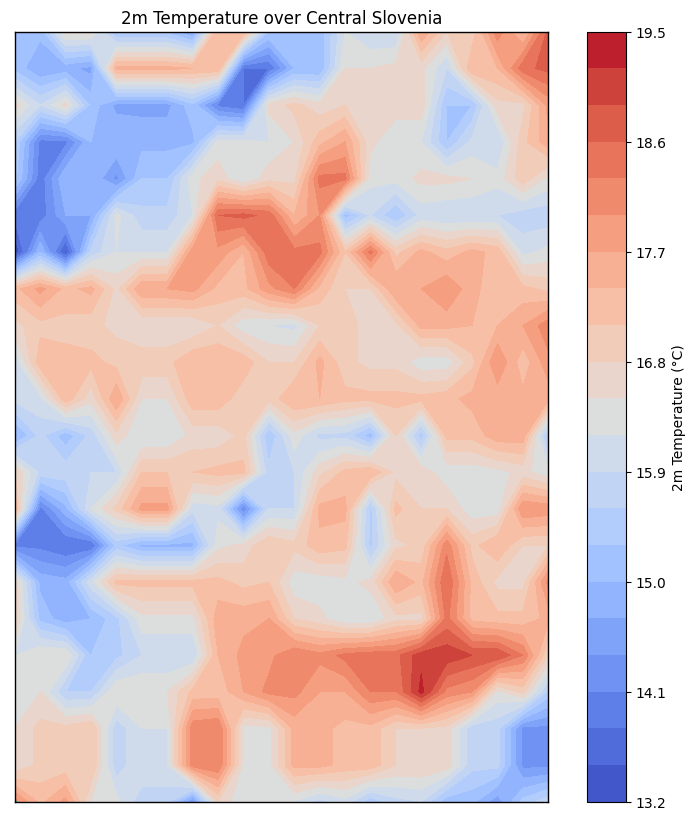

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

import os
from dotenv import load_dotenv
load_dotenv()

base_url = os.getenv('BASE_URL')

# Define the central coordinates for Slovenia
latitude_center, longitude_center = 46.1512, 14.9955

# Define a bounding box around the center with approximately 2 km resolution
lat_min = latitude_center - 0.2
lat_max = latitude_center + 0.2
lon_min = longitude_center - 0.2
lon_max = longitude_center + 0.2

# Grid for latitude and longitude with approximately 2 km resolution
lat_values = np.linspace(lat_min, lat_max, int((lat_max - lat_min) / 0.018))
lon_values = np.linspace(lon_min, lon_max, int((lon_max - lon_min) / 0.018))

temperature_2m = []

# Print a starting message
print("Starting to fetch data...")

# Loop through the grid and fetch the temperature values
for i, lat in enumerate(lat_values):
    for j, lon in enumerate(lon_values):
        # Build the API URL
        url = f"https://{base_url}/v1/dwd-icon?latitude={lat}&longitude={lon}&hourly=temperature_2m"
        
        # Fetch data
        response = requests.get(url)
        data = response.json()

        # Extract 2m temperature
        temp = data['hourly']['temperature_2m'][0]
        temperature_2m.append(temp)

        # Print progress update
        progress_percentage = (i * len(lon_values) + j + 1) / (len(lat_values) * len(lon_values)) * 100
        print(f"Progress: {progress_percentage:.2f}% complete")

# Print completion message
print("Data fetching complete.")

# Reshape the temperature data to match the grid shape
temperature_2m = np.reshape(temperature_2m, (len(lat_values), len(lon_values)))

# Create the map using Basemap
plt.figure(figsize=(10, 10))
m = Basemap(projection='merc', llcrnrlat=lat_min, urcrnrlat=lat_max, llcrnrlon=lon_min, urcrnrlon=lon_max, resolution='i')
m.drawcoastlines()
m.drawcountries()
m.drawmapboundary(fill_color='aqua')

# Convert lat and lon to map coordinates
lon_values_map, lat_values_map = np.meshgrid(lon_values, lat_values)
x, y = m(lon_values_map, lat_values_map)

# Plot the temperature data
cp = m.contourf(x, y, temperature_2m, 20, cmap='coolwarm')
plt.colorbar(cp, label="2m Temperature (°C)")

plt.title("2m Temperature over Central Slovenia")
plt.show()
